##### Copyright 2022 The TensorFlow Authors.

In [ ]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

<style>
td {
  text-align: center;
}

th {
  text-align: center;
}
</style>

# Traducción automática neuronal con un Transformer y Keras

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/text/tutorials/transformer">
    <img src="https://www.tensorflow.org/images/tf_logo_32px.png" />
    Ver en TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/text/blob/master/docs/tutorials/transformer.ipynb">
    <img src="https://www.tensorflow.org/images/colab_logo_32px.png" />
    Ejecutar en Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/text/blob/master/docs/tutorials/transformer.ipynb">
    <img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />
    Ver código fuente en GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/text/docs/tutorials/transformer.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Descargar notebook</a>
  </td>
</table>

Este tutorial muestra cómo crear y entrenar un modelo [Transformer](https://developers.google.com/machine-learning/glossary#Transformer) [secuencia a secuencia](https://developers.google.com/machine-learning/glossary#sequence-to-sequence-task) para traducir [portugués a inglés](https://www.tensorflow.org/datasets/catalog/ted_hrlr_translate#ted_hrlr_translatept_to_en). El Transformer fue propuesto originalmente por Vaswani et al. (2017) en ["Attention is all you need"](https://arxiv.org/abs/1706.03762).

Los Transformers son redes neuronales profundas que sustituyen las CNN y las RNN por [autoatención](https://developers.google.com/machine-learning/glossary#self-attention). La autoatención permite que la información fluya con facilidad entre posiciones de una secuencia, incluso cuando están muy alejadas.

Tal como se explica en el [Google AI Blog](https://ai.googleblog.com/2017/08/transformer-novel-neural-network.html):

> Las redes neuronales para traducción automática suelen contener un codificador que lee la frase de entrada y genera una representación de ella. Después, un decodificador genera la frase de salida palabra a palabra mientras consulta la representación creada por el codificador. El Transformer empieza generando representaciones iniciales, o embeddings, para cada palabra... A continuación, mediante autoatención, agrega información de todas las demás palabras y genera una nueva representación por palabra informada por todo el contexto, representado por los círculos rellenos. Este paso se repite varias veces en paralelo para todas las palabras, generando sucesivamente nuevas representaciones.

<img src="https://www.tensorflow.org/images/tutorials/transformer/apply_the_transformer_to_machine_translation.gif" alt="Aplicación del Transformer a la traducción automática">

Figura 1: Aplicación del Transformer a la traducción automática. Fuente: [Google AI Blog](https://ai.googleblog.com/2017/08/transformer-novel-neural-network.html).


Hay bastantes ideas en juego; el objetivo de este tutorial es descomponerlas en piezas fáciles de seguir. En este notebook vas a:

- Preparar los datos.
- Implementar los componentes necesarios:
  - Embeddings posicionales.
  - Capas de atención.
  - Codificador y decodificador.
- Construir y entrenar el Transformer.
- Generar traducciones.
- Exportar el modelo.

Para aprovechar mejor este tutorial conviene conocer [los fundamentos de la generación de texto](./text_generation.ipynb) y los mecanismos de atención.

Un Transformer es un modelo codificador-decodificador secuencia a secuencia, similar al modelo del tutorial de [NMT con atención](https://www.tensorflow.org/text/tutorials/nmt_with_attention).
Un Transformer de una sola capa requiere algo más de código, pero es casi idéntico a ese modelo RNN codificador-decodificador. La diferencia principal es que las capas RNN se sustituyen por capas de autoatención.
Este tutorial construye un Transformer de 4 capas, más grande y potente, pero no más complejo en lo fundamental.

<table>
<tr>
  <th>El <a href=https://www.tensorflow.org/text/tutorials/nmt_with_attention>modelo RNN+Atención</a></th>
  <th>Un Transformer de 1 capa</th>
</tr>
<tr>
  <td>
   <img width=411 src="https://www.tensorflow.org/images/tutorials/transformer/RNN+attention-words.png"/>
  </td>
  <td>
   <img width=400 src="https://www.tensorflow.org/images/tutorials/transformer/Transformer-1layer-words.png"/>
  </td>
</tr>
</table>

Después de entrenar el modelo de este notebook, podrás introducir una frase en portugués y obtener su traducción al inglés.

<img src="https://www.tensorflow.org/images/tutorials/transformer/attention_map_portuguese.png" alt="Mapa de calor de atención">

Figura 2: Pesos de atención visualizados que podrás generar al final del tutorial.

## Por qué los Transformers son importantes

- Los Transformers destacan en el modelado de datos secuenciales, como el lenguaje natural.
- A diferencia de las [redes neuronales recurrentes (RNN)](./text_generation.ipynb), los Transformers son paralelizables. Esto los hace eficientes en hardware como GPU y TPU. La razón principal es que reemplazan la recurrencia por atención, de modo que muchos cálculos pueden realizarse simultáneamente: las salidas de una capa se pueden calcular en paralelo, en lugar de paso a paso como en una RNN.
- A diferencia de las [RNN](https://www.tensorflow.org/guide/keras/rnn) (por ejemplo, [seq2seq, 2014](https://arxiv.org/abs/1409.3215)) o de las [redes neuronales convolucionales (CNN)](https://www.tensorflow.org/tutorials/images/cnn) (por ejemplo, [ByteNet](https://arxiv.org/abs/1610.10099)), los Transformers pueden capturar contextos y dependencias de largo alcance entre posiciones alejadas de las secuencias de entrada o salida. La atención permite que cada posición acceda a toda la entrada en cada capa; en RNN y CNN, la información debe atravesar muchos pasos de procesamiento para recorrer grandes distancias, lo que dificulta el aprendizaje.
- Los Transformers no imponen supuestos fuertes sobre relaciones temporales o espaciales en los datos. Esto resulta útil para procesar conjuntos de objetos, por ejemplo [unidades de StarCraft](https://www.deepmind.com/blog/alphastar-mastering-the-real-time-strategy-game-starcraft-ii).

<img src="https://www.tensorflow.org/images/tutorials/transformer/encoder_self_attention_distribution.png" width="800" alt="Distribución de autoatención del codificador para la palabra it desde la quinta hasta la sexta capa de un Transformer entrenado en traducción inglés-francés">

Figura 3: Distribución de autoatención del codificador para la palabra “it” desde la quinta hasta la sexta capa de un Transformer entrenado en traducción inglés-francés (una de ocho cabezas de atención). Fuente: [Google AI Blog](https://ai.googleblog.com/2017/08/transformer-novel-neural-network.html).

## Configuración

Empieza instalando [TensorFlow Datasets](https://tensorflow.org/datasets) para cargar el conjunto de datos y [TensorFlow Text](https://www.tensorflow.org/text) para el preprocesamiento de texto:

In [ ]:
# Instala una versión reciente de TensorFlow para usar el soporte mejorado
# de máscaras en `tf.keras.layers.MultiHeadAttention`.
!apt install --allow-change-held-packages libcudnn8=8.1.0.77-1+cuda11.2
!pip uninstall -y -q tensorflow keras tensorflow-estimator tensorflow-text
!pip install protobuf~=3.20.3
!pip install -q tensorflow_datasets
!pip install -q -U tensorflow-text tensorflow

Importa los módulos necesarios:

In [1]:
import logging
import os 
import time

import numpy as np
import matplotlib.pyplot as plt

import tensorflow_datasets as tfds
import tensorflow as tf

import tensorflow_text

2026-05-14 17:33:20.913806: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Gestión de datos

Esta sección descarga el conjunto de datos y el tokenizador de subpalabras, procedentes de [este tutorial](https://www.tensorflow.org/text/guide/subwords_tokenizer), y lo empaqueta todo en un `tf.data.Dataset` para el entrenamiento.


### Descargar el conjunto de datos

Usa TensorFlow Datasets para cargar el [conjunto de traducción portugués-inglés](https://www.tensorflow.org/datasets/catalog/ted_hrlr_translate#ted_hrlr_translatept_to_en) del TED Talks Open Translation Project. Este conjunto contiene aproximadamente 52.000 ejemplos de entrenamiento, 1.200 de validación y 1.800 de prueba.

In [2]:
examples, metadata = tfds.load('ted_hrlr_translate/pt_to_en',
                               with_info=True,
                               as_supervised=True)

train_examples, val_examples = examples['train'], examples['validation']

El objeto `tf.data.Dataset` devuelto por TensorFlow Datasets produce pares de ejemplos de texto:

In [3]:
for pt_examples, en_examples in train_examples.batch(3).take(1):
  print('> Ejemplos en portugués:')
  for i, pt in enumerate(pt_examples.numpy(), start=1):
    print("\t [{}]".format(i), pt.decode('utf-8'))
  print()

  print('> Ejemplos en inglés:')
  for i, en in enumerate(en_examples.numpy(), start=1):
    print("\t [{}]".format(i), en.decode('utf-8'))

> Ejemplos en portugués:
	 [1] e quando melhoramos a procura , tiramos a única vantagem da impressão , que é a serendipidade .
	 [2] mas e se estes fatores fossem ativos ?
	 [3] mas eles não tinham a curiosidade de me testar .

> Ejemplos en inglés:
	 [1] and when you improve searchability , you actually take away the one advantage of print , which is serendipity .
	 [2] but what if it were active ?
	 [3] but they did n't test for curiosity .


2026-05-14 17:34:37.519761: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-05-14 17:34:37.522126: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Configurar el tokenizador

Ahora que has cargado el conjunto de datos, necesitas tokenizar el texto para que cada elemento quede representado como un [token](https://developers.google.com/machine-learning/glossary#token) o como un ID de token, es decir, una representación numérica.

La tokenización es el proceso de dividir un texto en "tokens". Según el tokenizador, estos tokens pueden representar fragmentos de frase, palabras, subpalabras o caracteres. Para aprender más sobre tokenización, consulta [esta guía](https://www.tensorflow.org/text/guide/tokenizers).

Este tutorial usa los tokenizadores creados en el tutorial de [tokenizador de subpalabras](https://www.tensorflow.org/text/guide/subwords_tokenizer). Ese tutorial optimiza dos objetos `text.BertTokenizer` (uno para inglés y otro para portugués) para **este conjunto de datos** y los exporta en formato TensorFlow `saved_model`.

> Nota: Esto difiere del [artículo original](https://arxiv.org/pdf/1706.03762.pdf), sección 5.1, donde se utilizaba un único tokenizador byte-pair para origen y destino con un tamaño de vocabulario de 37.000.

Descarga, extrae e importa el `saved_model`:

In [4]:
tokenizer_model_name = 'ted_hrlr_translate_pt_en_converter'
tf.keras.utils.get_file(
    f'{tokenizer_model_name}.zip',
    f'https://storage.googleapis.com/download.tensorflow.org/models/{tokenizer_model_name}.zip',
    cache_dir='.', cache_subdir='', extract=True
)

184801/184801 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step


'./ted_hrlr_translate_pt_en_converter_extracted'

In [5]:
folder_name = os.path.join(tokenizer_model_name + "_extracted", tokenizer_model_name)
tokenizers = tf.saved_model.load(folder_name)

El `tf.saved_model` contiene dos tokenizadores de texto, uno para inglés y otro para portugués. Ambos tienen los mismos métodos:

In [6]:
[item for item in dir(tokenizers) if not item.startswith('_')]

['en',
 'graph_debug_info',
 'pt',
 'signatures',
 'tensorflow_git_version',
 'tensorflow_version']

In [7]:
[item for item in dir(tokenizers.en) if not item.startswith('_')]

['detokenize',
 'get_reserved_tokens',
 'get_vocab_path',
 'get_vocab_size',
 'lookup',
 'tokenize',
 'tokenizer',
 'vocab']

El método `tokenize` convierte un lote de cadenas en un lote rellenado de IDs de token. Este método separa la puntuación, convierte a minúsculas y normaliza Unicode antes de tokenizar. Esa estandarización no se aprecia aquí porque los datos de entrada ya están estandarizados.

In [8]:
print('> Esto es un lote de cadenas:')
for i, en in enumerate(en_examples.numpy(), start=1):
  print("\t [{}]".format(i), en.decode('utf-8'))

> Esto es un lote de cadenas:
	 [1] and when you improve searchability , you actually take away the one advantage of print , which is serendipity .
	 [2] but what if it were active ?
	 [3] but they did n't test for curiosity .


In [9]:
encoded = tokenizers.en.tokenize(en_examples)

print('> Esto es un lote rellenado de IDs de token:')
for i, row in enumerate(encoded.to_list(), start=1):
  print("\t [{}]".format(i), row)

> Esto es un lote rellenado de IDs de token:
	 [1] [2, 72, 117, 79, 1259, 1491, 2362, 13, 79, 150, 184, 311, 71, 103, 2308, 74, 2679, 13, 148, 80, 55, 4840, 1434, 2423, 540, 15, 3]
	 [2] [2, 87, 90, 107, 76, 129, 1852, 30, 3]
	 [3] [2, 87, 83, 149, 50, 9, 56, 664, 85, 2512, 15, 3]


El método `detokenize` intenta convertir estos IDs de token de nuevo en texto legible por una persona:

In [10]:
round_trip = tokenizers.en.detokenize(encoded)

print('> Esto es texto legible por una persona:')
for i, line in enumerate(round_trip.numpy(), start=1):
  print("\t [{}]".format(i), line.decode('utf-8'))

> Esto es texto legible por una persona:
	 [1] and when you improve searchability , you actually take away the one advantage of print , which is serendipity .
	 [2] but what if it were active ?
	 [3] but they did n ' t test for curiosity .


El método de nivel inferior `lookup` convierte IDs de token en texto de token:

In [11]:
print('> Este es el texto dividido en tokens:')
tokens = tokenizers.en.lookup(encoded)
tokens

> Este es el texto dividido en tokens:


<tf.RaggedTensor [[b'[START]', b'and', b'when', b'you', b'improve', b'search', b'##ability',
  b',', b'you', b'actually', b'take', b'away', b'the', b'one', b'advantage',
  b'of', b'print', b',', b'which', b'is', b's', b'##ere', b'##nd', b'##ip',
  b'##ity', b'.', b'[END]']                                                 ,
 [b'[START]', b'but', b'what', b'if', b'it', b'were', b'active', b'?',
  b'[END]']                                                           ,
 [b'[START]', b'but', b'they', b'did', b'n', b"'", b't', b'test', b'for',
  b'curiosity', b'.', b'[END]']                                          ]>

La salida muestra el aspecto de "subpalabra" de la tokenización por subpalabras.

Por ejemplo, la palabra `'searchability'` se descompone en `'search'` y `'##ability'`, y la palabra `'serendipity'` en `'s'`, `'##ere'`, `'##nd'`, `'##ip'` y `'##ity'`.

Observa que el texto tokenizado incluye los tokens `'[START]'` y `'[END]'`.

La distribución de tokens por ejemplo en el conjunto de datos es la siguiente:

In [12]:
lengths = []

for pt_examples, en_examples in train_examples.batch(1024):
  pt_tokens = tokenizers.pt.tokenize(pt_examples)
  lengths.append(pt_tokens.row_lengths())

  en_tokens = tokenizers.en.tokenize(en_examples)
  lengths.append(en_tokens.row_lengths())
  print('.', end='', flush=True)

...................................................

2026-05-14 17:35:14.108023: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


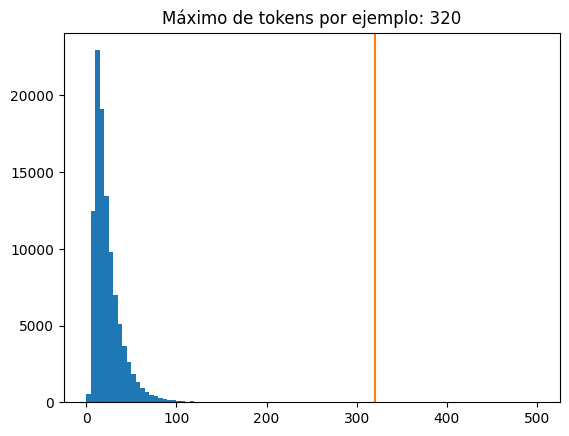

In [13]:
all_lengths = np.concatenate(lengths)

plt.hist(all_lengths, np.linspace(0, 500, 101))
plt.ylim(plt.ylim())
max_length = max(all_lengths)
plt.plot([max_length, max_length], plt.ylim())
plt.title(f'Máximo de tokens por ejemplo: {max_length}');

### Configurar una pipeline de datos con `tf.data`

La siguiente función recibe lotes de texto como entrada y los convierte a un formato adecuado para el entrenamiento.

1. Los tokeniza en lotes irregulares (`RaggedTensor`).
2. Recorta cada secuencia para que no supere `MAX_TOKENS`.
3. Divide los tokens objetivo (inglés) en entradas y etiquetas. Están desplazados un paso, de modo que en cada posición de entrada la `label` sea el ID del siguiente token.
4. Convierte los `RaggedTensor` en `Tensor` densos con relleno.
5. Devuelve un par `(inputs, labels)`.


In [14]:
MAX_TOKENS=128
def prepare_batch(pt, en):
    pt = tokenizers.pt.tokenize(pt)      # La salida es irregular (`RaggedTensor`).
    pt = pt[:, :MAX_TOKENS]    # Recorta a MAX_TOKENS.
    pt = pt.to_tensor()  # Convierte a un Tensor denso rellenado con 0.

    en = tokenizers.en.tokenize(en)
    en = en[:, :(MAX_TOKENS+1)]
    en_inputs = en[:, :-1].to_tensor()  # Elimina los tokens [END].
    en_labels = en[:, 1:].to_tensor()   # Elimina los tokens [START].

    return (pt, en_inputs), en_labels

La función siguiente convierte un conjunto de ejemplos de texto en lotes preparados para entrenamiento.

1. Tokeniza el texto y descarta las secuencias demasiado largas.
   (El `batch`/`unbatch` se incluye porque el tokenizador es mucho más eficiente con lotes grandes).
2. El método `cache` garantiza que ese trabajo se ejecute una sola vez.
3. Después, `shuffle` y el batching aleatorizan el orden y ensamblan lotes de ejemplos.
4. Finalmente, `prefetch` ejecuta la preparación de datos en paralelo con el modelo para asegurar que haya datos disponibles cuando se necesiten. Consulta [Mejor rendimiento con `tf.data`](https://www.tensorflow.org/guide/data_performance.ipynb) para más detalles.

In [15]:
BUFFER_SIZE = 20000
BATCH_SIZE = 64

In [16]:
def make_batches(ds):
  return (
      ds
      .shuffle(BUFFER_SIZE)
      .batch(BATCH_SIZE)
      .map(prepare_batch, tf.data.AUTOTUNE)
      .prefetch(buffer_size=tf.data.AUTOTUNE))

 </section>

## Probar el `Dataset`

In [17]:
# Crea lotes para entrenamiento y validación.
train_batches = make_batches(train_examples)
val_batches = make_batches(val_examples)

Los objetos `tf.data.Dataset` resultantes están preparados para entrenar con Keras.
El entrenamiento con `Model.fit` en Keras espera pares `(inputs, labels)`.
Las `inputs` son pares de secuencias tokenizadas de portugués e inglés, `(pt, en)`.
Las `labels` son las mismas secuencias en inglés desplazadas 1 posición.
Este desplazamiento hace que, para cada posición de la secuencia de entrada `en`, la `label` sea el siguiente token.


<table>
<tr>
  <th>Entradas abajo, etiquetas arriba.</th>
</tr>
<tr>
  <td>
   <img width=400 src="https://www.tensorflow.org/images/tutorials/transformer/Transformer-1layer-words.png"/>
  </td>
</tr>
</table>

Esto es lo mismo que en el [tutorial de generación de texto](text_generation.ipynb), salvo que aquí hay una entrada adicional de "contexto" (la secuencia en portugués) sobre la que el modelo queda condicionado.

Esta configuración se llama *teacher forcing* porque, independientemente de la salida que produzca el modelo en cada paso temporal, durante el entrenamiento recibe como entrada el valor real del paso anterior.
Es una forma sencilla y eficiente de entrenar un modelo generativo de texto.
Es eficiente porque no obliga a ejecutar el modelo de forma estrictamente secuencial: las salidas en las distintas posiciones de la secuencia pueden calcularse en paralelo.

Quizá esperarías que los pares `input, output` fueran simplemente las secuencias `Portuguese, English`.
Dada la secuencia en portugués, el modelo intentaría generar la secuencia en inglés.

Es posible entrenar un modelo de esa manera, pero habría que escribir explícitamente el bucle de inferencia y volver a introducir la salida del modelo como entrada.
Ese enfoque es más lento (los pasos temporales no pueden ejecutarse en paralelo) y la tarea es más difícil de aprender (el modelo no puede acertar bien el final de una frase hasta haber generado bien el principio), aunque puede producir modelos más robustos porque el modelo aprende a convivir con sus propios errores durante el entrenamiento.

In [18]:
for (pt, en), en_labels in train_batches.take(1):
  break

print(pt.shape)
print(en.shape)
print(en_labels.shape)

(64, 74)
(64, 64)
(64, 64)


`en` y `en_labels` son iguales, solo que desplazados 1 posición:

In [19]:
print(en[0][:10])
print(en_labels[0][:10])

tf.Tensor([  2  10 189  11 192  91  45 321  81  30], shape=(10,), dtype=int64)
tf.Tensor([ 10 189  11 192  91  45 321  81  30   3], shape=(10,), dtype=int64)


## Definir los componentes

Dentro de un Transformer ocurren muchas cosas. Las ideas importantes son:

1. Sigue el mismo patrón general que un modelo secuencia a secuencia estándar, con un codificador y un decodificador.
2. Si se analiza paso a paso, cada bloque tiene un propósito claro.

<table>
<tr>
  <th colspan=1>Diagrama original del Transformer</th>
  <th colspan=1>Representación de un Transformer de 4 capas</th>
</tr>
<tr>
  <td>
   <img width=400 src="https://www.tensorflow.org/images/tutorials/transformer/transformer.png"/>
  </td>
  <td>
   <img width=307 src="https://www.tensorflow.org/images/tutorials/transformer/Transformer-4layer-compact.png"/>
  </td>
</tr>
</table>

Cada componente de estos dos diagramas se explicará a medida que avances por el tutorial.

### Capa de embedding y codificación posicional

Las entradas del codificador y del decodificador usan la misma lógica de embedding y codificación posicional.

<table>
<tr>
  <th colspan=1>Capa de embedding y codificación posicional</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/PositionalEmbedding.png"/>
  </td>
</tr>
</table>

Dada una secuencia de tokens, tanto los tokens de entrada (portugués) como los tokens objetivo (inglés) deben convertirse en vectores mediante una capa `tf.keras.layers.Embedding`.

Las capas de atención usadas en todo el modelo reciben su entrada como un conjunto de vectores, sin un orden explícito. Como el modelo no contiene capas recurrentes ni convolucionales, necesita alguna forma de identificar el orden de las palabras; de lo contrario vería la secuencia como una instancia de [bolsa de palabras](https://developers.google.com/machine-learning/glossary#bag-of-words): `how are you`, `how you are`, `you how are`, etc. serían indistinguibles.

Un Transformer añade una "codificación posicional" a los vectores de embedding. En este caso utiliza senos y cosenos a distintas frecuencias a lo largo de la secuencia. Por construcción, posiciones cercanas tienen codificaciones similares, y el modelo puede aprender a explotar relaciones relativas entre posiciones.

El artículo original usa la siguiente fórmula para calcular la codificación posicional:

$$ PE_{(pos, 2i)} = \sin\left(
\frac{pos}{10000^{
\frac{2i}{d_{model}}}}
\right) $$
$$ PE_{(pos, 2i+1)} = \cos\left(
\frac{pos}{10000^{
\frac{2i}{d_{model}}}}
\right) $$

> Nota: El código siguiente implementa esta idea, pero en lugar de intercalar senos y cosenos, concatena los vectores de senos y cosenos. Esta permutación de canales es funcionalmente equivalente y resulta un poco más sencilla de implementar y visualizar en los gráficos siguientes.

In [20]:
def positional_encoding(length, depth):
  """
  Genera la codificación posicional para una secuencia.

  Args:
    length: int, longitud de la secuencia (número de posiciones).
    depth: int, dimensionalidad del embedding.

  Returns:
    Tensor de forma (length, depth) con las codificaciones posicionales.
  """
  depth = depth/2

  positions = np.arange(length)[:, np.newaxis]     # (seq, 1)
  depths = np.arange(depth)[np.newaxis, :]/depth   # (1, depth)

  angle_rates = 1 / (10000**depths)         # (1, depth)
  angle_rads = positions * angle_rates      # (pos, depth)

  pos_encoding = np.concatenate(
      [np.sin(angle_rads), np.cos(angle_rads)],
      axis=-1)

  return tf.cast(pos_encoding, dtype=tf.float32)

La función de codificación posicional es una pila de senos y cosenos que oscilan a distintas frecuencias según su posición dentro de la profundidad del vector de embedding. Las oscilaciones se producen a lo largo del eje de posición.

(2048, 512)


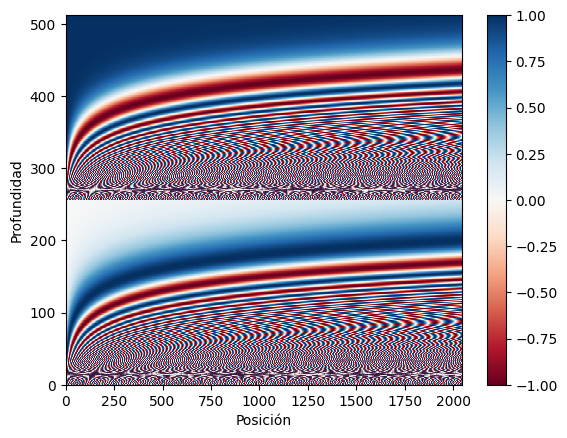

In [21]:
#@title
pos_encoding = positional_encoding(length=2048, depth=512)

# Comprueba la forma.
print(pos_encoding.shape)

# Representa las dimensiones.
plt.pcolormesh(pos_encoding.numpy().T, cmap='RdBu')
plt.ylabel('Profundidad')
plt.xlabel('Posición')
plt.colorbar()
plt.show()

Por construcción, estos vectores se alinean bien con vectores de posiciones cercanas. A continuación se normalizan los vectores de codificación posicional y se compara el vector de la posición `1000`, mediante producto escalar, con todos los demás:

(0.0, 1.0)

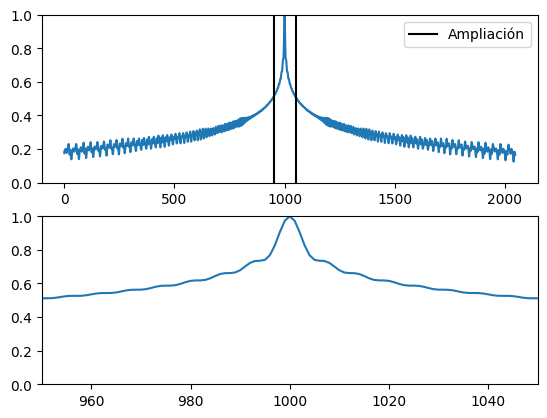

In [22]:
#@title
pos_encoding/=tf.norm(pos_encoding, axis=1, keepdims=True)
p = pos_encoding[1000]
dots = tf.einsum('pd,d -> p', pos_encoding, p)
plt.subplot(2,1,1)
plt.plot(dots)
plt.ylim([0,1])
plt.plot([950, 950, float('nan'), 1050, 1050],
         [0,1,float('nan'),0,1], color='k', label='Ampliación')
plt.legend()
plt.subplot(2,1,2)
plt.plot(dots)
plt.xlim([950, 1050])
plt.ylim([0,1])


Usa esto para crear una capa `PositionEmbedding` que busque el vector de embedding de cada token y le sume el vector posicional correspondiente:

In [23]:
class PositionalEmbedding(tf.keras.layers.Layer):
  def __init__(self, vocab_size, d_model):
    super().__init__()
    self.d_model = d_model
    self.embedding = tf.keras.layers.Embedding(vocab_size, d_model, mask_zero=True)
    self.pos_encoding = positional_encoding(length=2048, depth=d_model)

  def compute_mask(self, *args, **kwargs):
    return self.embedding.compute_mask(*args, **kwargs)

  def call(self, x):
    length = tf.shape(x)[1]
    x = self.embedding(x)
    # Este factor fija la escala relativa del embedding y la codificación posicional.
    x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
    x = x + self.pos_encoding[tf.newaxis, :length, :]
    return x


> Nota: El [artículo original](https://arxiv.org/pdf/1706.03762.pdf), secciones 3.4 y 5.1, utiliza un único tokenizador y una única matriz de pesos para los idiomas origen y destino. Este tutorial usa dos tokenizadores y dos matrices de pesos independientes.

In [24]:
embed_pt = PositionalEmbedding(vocab_size=tokenizers.pt.get_vocab_size().numpy(), d_model=512)
embed_en = PositionalEmbedding(vocab_size=tokenizers.en.get_vocab_size().numpy(), d_model=512)

pt_emb = embed_pt(pt)
en_emb = embed_en(en)

In [25]:
en_emb._keras_mask

<tf.Tensor: shape=(64, 64), dtype=bool, numpy=
array([[ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       ...,
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False]])>

### Suma y normalización

<table>
<tr>
  <th colspan=2>Suma y normalización</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/Add+Norm.png"/>
  </td>
</tr>
</table>

Los bloques "Add & Norm" aparecen en todo el modelo. Cada uno combina una conexión residual y después pasa el resultado por una capa `LayerNormalization`.

La forma más clara de organizar el código es alrededor de estos bloques residuales. Las siguientes secciones definen clases de capa personalizadas para cada caso.

Los bloques residuales "Add & Norm" ayudan a que el entrenamiento sea eficiente. La conexión residual ofrece un camino directo para el gradiente y garantiza que las capas de atención **actualicen** los vectores en lugar de **reemplazarlos** por completo, mientras que la normalización mantiene una escala razonable en las salidas.

> Nota: Las implementaciones siguientes usan la capa `Add` para asegurar que las máscaras de Keras se propaguen correctamente (el operador `+` no lo hace).


### Capa base de atención

Las capas de atención se usan en todo el modelo. Son idénticas salvo por la forma en que se configura la atención. Cada una contiene una `layers.MultiHeadAttention`, una `layers.LayerNormalization` y una `layers.Add`.

<table>
<tr>
  <th colspan=2>Capa base de atención</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/BaseAttention.png"/>
  </td>
</tr>
</table>

Para implementar estas capas de atención, empieza con una clase base sencilla que contiene las capas componentes. Cada caso de uso se implementará como una subclase. Requiere algo más de código, pero deja clara la intención de cada variante.

In [26]:
class BaseAttention(tf.keras.layers.Layer):
  def __init__(self, **kwargs):
    super().__init__()
    self.mha = tf.keras.layers.MultiHeadAttention(**kwargs)
    self.layernorm = tf.keras.layers.LayerNormalization()
    self.add = tf.keras.layers.Add()

#### Repaso rápido de atención

Antes de entrar en los detalles de cada uso, conviene repasar cómo funciona la atención:

<table>
<tr>
  <th colspan=1>Capa base de atención</th>
</tr>
<tr>
  <td>
   <img width=430 src="https://www.tensorflow.org/images/tutorials/transformer/BaseAttention-new.png"/>
  </td>
</tr>
</table>

Hay dos entradas:

1. La secuencia de consulta (`query`): la secuencia que se está procesando y que "atiende" a otra información (abajo en el diagrama).
2. La secuencia de contexto: la secuencia a la que se atiende (izquierda en el diagrama).

La salida tiene la misma forma que la secuencia `query`.

Una comparación útil es pensar en esta operación como una búsqueda en un diccionario: una búsqueda **difusa**, **diferenciable** y **vectorizada**.

Este es un diccionario normal de Python, con 3 claves y 3 valores, al que se le pasa una única consulta.

```
d = {'color': 'blue', 'age': 22, 'type': 'pickup'}
result = d['color']
```

- La `query` es lo que estás intentando encontrar.
- Las `key` indican qué tipo de información contiene el diccionario.
- El `value` es la información asociada.

Cuando buscas una `query` en un diccionario normal, el diccionario encuentra la `key` coincidente y devuelve su `value` asociado.
La `query` tiene una `key` coincidente o no la tiene.
Puedes imaginar un diccionario **difuso** donde las claves no tienen que coincidir de forma perfecta.
Si buscaras `d["species"]` en el diccionario anterior, quizá querrías que devolviera `"pickup"` porque es la mejor coincidencia disponible.

Una capa de atención hace una búsqueda difusa de este tipo, pero no se limita a escoger la mejor clave.
Combina los `values` según lo bien que la `query` coincide con cada `key`.

¿Cómo funciona? En una capa de atención, `query`, `key` y `value` son vectores.
En lugar de hacer una búsqueda por hash, la capa combina los vectores `query` y `key` para estimar lo bien que encajan; ese valor es la "puntuación de atención".
La capa devuelve una media ponderada de todos los `values`, usando esas puntuaciones de atención como pesos.

Cada posición de la secuencia `query` aporta un vector `query`.
La secuencia de contexto actúa como el diccionario: en cada posición aporta un vector `key` y un vector `value`.
Los vectores de entrada no se usan directamente; la capa `layers.MultiHeadAttention` incluye capas `layers.Dense` que proyectan los vectores antes de usarlos.

### Capa de atención cruzada

En el centro conceptual del Transformer está la capa de atención cruzada. Esta capa conecta el codificador y el decodificador. Es el uso más directo de la atención en el modelo y realiza una tarea equivalente al bloque de atención del tutorial de [NMT con atención](https://www.tensorflow.org/text/tutorials/nmt_with_attention).

<table>
<tr>
  <th colspan=1>Capa de atención cruzada</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/CrossAttention.png"/>
  </td>
</tr>
</table>

Para implementarla, pasa la secuencia objetivo `x` como `query` y la secuencia de `context` como `key/value` al llamar a la capa `mha`:

In [27]:
class CrossAttention(BaseAttention):
  def call(self, x, context):
    attn_output, attn_scores = self.mha(
        query=x,
        key=context,
        value=context,
        return_attention_scores=True)

    # Guarda las puntuaciones de atención para representarlas más adelante.
    self.last_attn_scores = attn_scores

    x = self.add([x, attn_output])
    x = self.layernorm(x)

    return x

El esquema siguiente muestra cómo fluye la información por esta capa. Las columnas representan la suma ponderada sobre la secuencia de contexto.

Para simplificar, no se muestran las conexiones residuales.

<table>
<tr>
  <th>Capa de atención cruzada</th>
</tr>
<tr>
  <td>
   <img width=430 src="https://www.tensorflow.org/images/tutorials/transformer/CrossAttention-new-full.png"/>
  </td>
</tr>
</table>

La longitud de la salida es la longitud de la secuencia `query`, no la longitud de la secuencia de contexto `key/value`.

El diagrama se simplifica aún más abajo. No hace falta dibujar toda la matriz de "pesos de atención".
La idea clave es que cada posición `query` puede ver todos los pares `key/value` del contexto, pero no se intercambia información entre las distintas consultas.

<table>
<tr>
  <th>Cada consulta ve todo el contexto.</th>
</tr>
<tr>
  <td>
   <img width=430 src="https://www.tensorflow.org/images/tutorials/transformer/CrossAttention-new.png"/>
  </td>
</tr>
</table>

Pruébala con entradas de ejemplo:

In [28]:
sample_ca = CrossAttention(num_heads=2, key_dim=512)

print(pt_emb.shape)
print(en_emb.shape)
print(sample_ca(en_emb, pt_emb).shape)

(64, 74, 512)
(64, 64, 512)
(64, 64, 512)


### Capa de autoatención global

Esta capa se encarga de procesar la secuencia de contexto y propagar información a lo largo de toda su longitud:

<table>
<tr>
  <th colspan=1>Capa de autoatención global</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/SelfAttention.png"/>
  </td>
</tr>
</table>

Como la secuencia de contexto queda fija mientras se genera la traducción, se permite que la información fluya en ambas direcciones.

Antes de los Transformers y la autoatención, era habitual usar RNN o CNN para esta tarea:

<table>
<tr>
  <th colspan=1>RNN bidireccionales y CNN</th>
</tr>
<tr>
  <td>
   <img width=500 src="https://www.tensorflow.org/images/tutorials/transformer/RNN-bidirectional.png"/>
  </td>
</tr>
<tr>
  <td>
   <img width=500 src="https://www.tensorflow.org/images/tutorials/transformer/CNN.png"/>
  </td>
</tr>
</table>

Las RNN y las CNN tienen limitaciones.

- Una RNN permite que la información fluya a lo largo de toda la secuencia, pero debe atravesar muchos pasos de procesamiento para llegar de una posición a otra, lo que limita el flujo de gradiente. Además, esos pasos recurrentes se ejecutan secuencialmente, por lo que la RNN aprovecha peor los dispositivos paralelos modernos.
- En una CNN, cada posición puede procesarse en paralelo, pero solo dispone de un campo receptivo limitado. Ese campo receptivo crece linealmente con el número de capas convolucionales, por lo que hacen falta muchas capas para transmitir información a lo largo de la secuencia ([Wavenet](https://arxiv.org/abs/1609.03499) reduce este problema usando convoluciones dilatadas).

La capa de autoatención global, en cambio, permite que cada elemento de la secuencia acceda directamente a cualquier otro elemento con pocas operaciones, y todas las salidas se pueden calcular en paralelo.

Para implementar esta capa basta con pasar la secuencia objetivo `x` como argumentos `query`, `key` y `value` de la capa `mha`:

In [29]:
class GlobalSelfAttention(BaseAttention):
  def call(self, x):
    attn_output = self.mha(
        query=x,
        value=x,
        key=x)
    x = self.add([x, attn_output])
    x = self.layernorm(x)
    return x

In [30]:
sample_gsa = GlobalSelfAttention(num_heads=2, key_dim=512)

print(pt_emb.shape)
print(sample_gsa(pt_emb).shape)

(64, 74, 512)
(64, 74, 512)


Siguiendo el mismo estilo anterior, podríamos dibujarla así:

<table>
<tr>
  <th colspan=1>Capa de autoatención global</th>
<tr>
<tr>
  <td>
   <img width=330 src="https://www.tensorflow.org/images/tutorials/transformer/SelfAttention-new-full.png"/>
  </td>
</tr>
</table>

De nuevo, se omiten las conexiones residuales para mayor claridad.

Es más compacto, e igual de correcto, dibujarlo así:

<table>
<tr>
  <th colspan=1>Capa de autoatención global</th>
<tr>
<tr>
  <td>
   <img width=500 src="https://www.tensorflow.org/images/tutorials/transformer/SelfAttention-new.png"/>
  </td>
</tr>
</table>

### Capa de autoatención causal

Esta capa realiza una función similar a la autoatención global, pero sobre la secuencia de salida:

<table>
<tr>
  <th colspan=1>Capa de autoatención causal</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/CausalSelfAttention.png"/>
  </td>
</tr>
</table>

Debe tratarse de forma distinta a la autoatención global del codificador.

Como en el [tutorial de generación de texto](https://www.tensorflow.org/text/tutorials/text_generation) y en el tutorial de [NMT con atención](https://www.tensorflow.org/text/tutorials/nmt_with_attention), los Transformers de este tipo son modelos "autorregresivos": generan texto token a token y reintroducen esa salida como entrada. Para hacerlo _eficiente_, estos modelos garantizan que la salida de cada elemento de la secuencia solo dependa de los elementos anteriores; por eso se dice que son "causales".

Una RNN unidireccional es causal por definición. Para crear una convolución causal basta con rellenar la entrada y desplazar la salida para que se alinee correctamente (usa `layers.Conv1D(padding='causal')`).

<table>
<tr>
  <th colspan=1>RNN y CNN causales</th>
</tr>
<tr>
  <td>
   <img width=500 src="https://www.tensorflow.org/images/tutorials/transformer/RNN.png"/>
  </td>
</tr>
<tr>
  <td>
   <img width=500 src="https://www.tensorflow.org/images/tutorials/transformer/CNN-causal.png"/>
  </td>
</tr>
</table>

Un modelo causal es eficiente de dos maneras:

1. Durante el entrenamiento permite calcular la pérdida en todas las posiciones de la secuencia de salida ejecutando el modelo una sola vez.
2. Durante la inferencia, para cada nuevo token generado solo necesitas calcular la salida correspondiente a ese nuevo token; las salidas de los elementos anteriores pueden reutilizarse.
  - En una RNN basta con conservar el estado recurrente de los cálculos previos (pasa `return_state=True` al constructor de la capa RNN).
  - En una CNN habría que seguir una estrategia como [Fast Wavenet](https://arxiv.org/abs/1611.09482).

Para construir una capa de autoatención causal, hay que usar una máscara adecuada al calcular las puntuaciones de atención y al sumar los `value` de atención.

Esto se gestiona automáticamente si pasas `use_causal_mask = True` a la capa `MultiHeadAttention` al llamarla:

In [31]:
class CausalSelfAttention(BaseAttention):
  def call(self, x):
    attn_output = self.mha(
        query=x,
        value=x,
        key=x,
        use_causal_mask = True)
    x = self.add([x, attn_output])
    x = self.layernorm(x)
    return x

La máscara causal garantiza que cada posición solo tenga acceso a las posiciones anteriores:

<table>
<tr>
  <th colspan=1>Capa de autoatención causal</th>
<tr>
<tr>
  <td>
   <img width=330 src="https://www.tensorflow.org/images/tutorials/transformer/CausalSelfAttention-new-full.png"/>
  </td>
</tr>
</table>

De nuevo, se omiten las conexiones residuales para simplificar.

Una representación más compacta de esta capa sería:

<table>
</tr>
  <th colspan=1>Capa de autoatención causal</th>
<tr>
<tr>
  <td>
   <img width=430 src="https://www.tensorflow.org/images/tutorials/transformer/CausalSelfAttention-new.png"/>
  </td>
</tr>
</table>

Prueba la capa:

In [32]:
sample_csa = CausalSelfAttention(num_heads=2, key_dim=512)

print(en_emb.shape)
print(sample_csa(en_emb).shape)

(64, 64, 512)
(64, 64, 512)


La salida de los primeros elementos de la secuencia no depende de los elementos posteriores, así que no debería importar si recortas elementos antes o después de aplicar la capa:

In [33]:
out1 = sample_csa(embed_en(en[:, :3]))
out2 = sample_csa(embed_en(en))[:, :3]

tf.reduce_max(abs(out1 - out2)).numpy()

/Users/albertorag/Documents/02. Trabajo/03. Pontia/01. Máster IA Generativa/03. Repositorio/pontia_ia25/sesion_01/.venv/lib/python3.11/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'causal_self_attention' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


5.9604645e-07

> Nota: Al usar máscaras de Keras, los valores de salida en posiciones no válidas no están bien definidos. Por tanto, lo anterior puede no cumplirse en regiones enmascaradas.

### Red feed-forward

El Transformer también incluye esta red feed-forward punto a punto tanto en el codificador como en el decodificador:

<table>
<tr>
  <th colspan=1>Red feed-forward</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/FeedForward.png"/>
  </td>
</tr>
</table>

La red consta de dos capas lineales (`tf.keras.layers.Dense`) con una activación ReLU entre ellas y una capa de dropout. Como en las capas de atención, el código también incluye la conexión residual y la normalización:

In [34]:
class FeedForward(tf.keras.layers.Layer):
  def __init__(self, d_model, dff, dropout_rate=0.1):
    super().__init__()
    self.seq = tf.keras.Sequential([
      tf.keras.layers.Dense(dff, activation='relu'),
      tf.keras.layers.Dense(d_model),
      tf.keras.layers.Dropout(dropout_rate)
    ])
    self.add = tf.keras.layers.Add()
    self.layer_norm = tf.keras.layers.LayerNormalization()

  def call(self, x):
    x = self.add([x, self.seq(x)])
    x = self.layer_norm(x)
    return x


Prueba la capa; la salida tiene la misma forma que la entrada:

In [35]:
sample_ffn = FeedForward(512, 2048)

print(en_emb.shape)
print(sample_ffn(en_emb).shape)

(64, 64, 512)
(64, 64, 512)


### Capa del codificador

El codificador contiene una pila de `N` capas de codificador. Cada `EncoderLayer` contiene una capa `GlobalSelfAttention` y una capa `FeedForward`:

<table>
<tr>
  <th colspan=1>Capa del codificador</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/EncoderLayer.png"/>
  </td>
</tr>
</table>

Esta es la definición de `EncoderLayer`:

In [36]:
class EncoderLayer(tf.keras.layers.Layer):
  def __init__(self,*, d_model, num_heads, dff, dropout_rate=0.1):
    super().__init__()

    self.self_attention = GlobalSelfAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    self.ffn = FeedForward(d_model, dff)

  def call(self, x):
    x = self.self_attention(x)
    x = self.ffn(x)
    return x

Y una prueba rápida: la salida tendrá la misma forma que la entrada:

In [37]:
sample_encoder_layer = EncoderLayer(d_model=512, num_heads=8, dff=2048)

print(pt_emb.shape)
print(sample_encoder_layer(pt_emb).shape)

(64, 74, 512)
(64, 74, 512)


### El codificador

A continuación, construye el codificador.

<table>
<tr>
  <th colspan=1>El codificador</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/Encoder.png"/>
  </td>
</tr>
</table>

El codificador consta de:

- Una capa `PositionalEmbedding` en la entrada.
- Una pila de capas `EncoderLayer`.

In [38]:
class Encoder(tf.keras.layers.Layer):
  def __init__(self, *, num_layers, d_model, num_heads,
               dff, vocab_size, dropout_rate=0.1):
    super().__init__()

    self.d_model = d_model
    self.num_layers = num_layers

    self.pos_embedding = PositionalEmbedding(
        vocab_size=vocab_size, d_model=d_model)

    self.enc_layers = [
        EncoderLayer(d_model=d_model,
                     num_heads=num_heads,
                     dff=dff,
                     dropout_rate=dropout_rate)
        for _ in range(num_layers)]
    self.dropout = tf.keras.layers.Dropout(dropout_rate)

  def call(self, x):
    # `x` contiene IDs de token con forma: (batch, seq_len)
    x = self.pos_embedding(x)  # Forma `(batch_size, seq_len, d_model)`.

    # Añade dropout.
    x = self.dropout(x)

    for i in range(self.num_layers):
      x = self.enc_layers[i](x)

    return x  # Forma `(batch_size, seq_len, d_model)`.

Prueba el codificador:

In [39]:
# Instancia el codificador.
sample_encoder = Encoder(num_layers=4,
                         d_model=512,
                         num_heads=8,
                         dff=2048,
                         vocab_size=8500)

sample_encoder_output = sample_encoder(pt, training=False)

# Imprime la forma.
print(pt.shape)
print(sample_encoder_output.shape)  # Forma `(batch_size, input_seq_len, d_model)`.

/Users/albertorag/Documents/02. Trabajo/03. Pontia/01. Máster IA Generativa/03. Repositorio/pontia_ia25/sesion_01/.venv/lib/python3.11/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'global_self_attention_2' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/albertorag/Documents/02. Trabajo/03. Pontia/01. Máster IA Generativa/03. Repositorio/pontia_ia25/sesion_01/.venv/lib/python3.11/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'encoder_layer_1' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


(64, 74)
(64, 74, 512)


### Capa del decodificador

La pila del decodificador es algo más compleja: cada `DecoderLayer` contiene una `CausalSelfAttention`, una `CrossAttention` y una capa `FeedForward`:  

<table>
<tr>
  <th colspan=1>Capa del decodificador</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/DecoderLayer.png"/>
  </td>
</tr>
</table>

In [40]:
class DecoderLayer(tf.keras.layers.Layer):
  def __init__(self,
               *,
               d_model,
               num_heads,
               dff,
               dropout_rate=0.1):
    super(DecoderLayer, self).__init__()

    self.causal_self_attention = CausalSelfAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    self.cross_attention = CrossAttention(
        num_heads=num_heads,
        key_dim=d_model,
        dropout=dropout_rate)

    self.ffn = FeedForward(d_model, dff)

  def call(self, x, context):
    x = self.causal_self_attention(x=x)
    x = self.cross_attention(x=x, context=context)

    # Guarda las últimas puntuaciones de atención para representarlas más adelante
    self.last_attn_scores = self.cross_attention.last_attn_scores

    x = self.ffn(x)  # Forma `(batch_size, seq_len, d_model)`.
    return x

Prueba la capa del decodificador:

In [41]:
sample_decoder_layer = DecoderLayer(d_model=512, num_heads=8, dff=2048)

sample_decoder_layer_output = sample_decoder_layer(
    x=en_emb, context=pt_emb)

print(en_emb.shape)
print(pt_emb.shape)
print(sample_decoder_layer_output.shape)  # `(batch_size, seq_len, d_model)`

(64, 64, 512)
(64, 74, 512)
(64, 64, 512)


### El decodificador

De forma similar al `Encoder`, el `Decoder` consta de una capa `PositionalEmbedding` y una pila de capas `DecoderLayer`:

<table>
<tr>
  <th colspan=1>Capa de embedding y codificación posicional</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/Decoder.png"/>
  </td>
</tr>
</table>

Define el decodificador extendiendo `tf.keras.layers.Layer`:

In [42]:
class Decoder(tf.keras.layers.Layer):
  def __init__(self, *, num_layers, d_model, num_heads, dff, vocab_size,
               dropout_rate=0.1):
    super(Decoder, self).__init__()

    self.d_model = d_model
    self.num_layers = num_layers

    self.pos_embedding = PositionalEmbedding(vocab_size=vocab_size,
                                             d_model=d_model)
    self.dropout = tf.keras.layers.Dropout(dropout_rate)
    self.dec_layers = [
        DecoderLayer(d_model=d_model, num_heads=num_heads,
                     dff=dff, dropout_rate=dropout_rate)
        for _ in range(num_layers)]

    self.last_attn_scores = None

  def call(self, x, context):
    # `x` is token-IDs shape (batch, target_seq_len)
    x = self.pos_embedding(x)  # (batch_size, target_seq_len, d_model)

    x = self.dropout(x)

    for i in range(self.num_layers):
      x  = self.dec_layers[i](x, context)

    self.last_attn_scores = self.dec_layers[-1].last_attn_scores

    # La forma de x es (batch_size, target_seq_len, d_model).
    return x

Prueba el decodificador:

In [43]:
# Instancia el decodificador.
sample_decoder = Decoder(num_layers=4,
                         d_model=512,
                         num_heads=8,
                         dff=2048,
                         vocab_size=8000)

output = sample_decoder(
    x=en,
    context=pt_emb)

# Imprime las formas.
print(en.shape)
print(pt_emb.shape)
print(output.shape)

/Users/albertorag/Documents/02. Trabajo/03. Pontia/01. Máster IA Generativa/03. Repositorio/pontia_ia25/sesion_01/.venv/lib/python3.11/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'causal_self_attention_2' (of type CausalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/albertorag/Documents/02. Trabajo/03. Pontia/01. Máster IA Generativa/03. Repositorio/pontia_ia25/sesion_01/.venv/lib/python3.11/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'decoder_layer_1' (of type DecoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


(64, 64)
(64, 74, 512)
(64, 64, 512)


In [44]:
sample_decoder.last_attn_scores.shape  # (batch, heads, target_seq, input_seq)

TensorShape([64, 8, 64, 74])

Una vez creados el codificador y el decodificador del Transformer, toca construir el modelo `Transformer` y entrenarlo.

## El Transformer

Ya tienes `Encoder` y `Decoder`. Para completar el modelo `Transformer`, hay que conectarlos y añadir una capa lineal final (`Dense`) que convierta el vector resultante en cada posición en probabilidades sobre los tokens de salida.

La salida del decodificador es la entrada de esta capa lineal final.

<table>
<tr>
  <th colspan=1>El Transformer</th>
<tr>
<tr>
  <td>
   <img src="https://www.tensorflow.org/images/tutorials/transformer/transformer.png"/>
  </td>
</tr>
</table>

Un `Transformer` con una capa en el `Encoder` y una capa en el `Decoder` se parece mucho al modelo del tutorial de [RNN+atención](https://www.tensorflow.org/text/tutorials/nmt_with_attention). Un Transformer multicapa tiene más capas, pero en esencia hace lo mismo.

<table>
<tr>
  <th colspan=1>Transformer de 1 capa</th>
  <th colspan=1>Transformer de 4 capas</th>
</tr>
<tr>
  <td>
   <img width=400 src="https://www.tensorflow.org/images/tutorials/transformer/Transformer-1layer-compact.png"/>
  </td>
  <td rowspan=3>
   <img width=330 src="https://www.tensorflow.org/images/tutorials/transformer/Transformer-4layer-compact.png"/>
  </td>
</tr>
<tr>
  <th colspan=1>Modelo RNN+Atención</th>
</tr>
<tr>
  <td>
   <img width=400 src="https://www.tensorflow.org/images/tutorials/transformer/RNN+attention-compact.png"/>
  </td>
</tr>
</table>

Crea el `Transformer` extendiendo `tf.keras.Model`:

> Nota: El [artículo original](https://arxiv.org/pdf/1706.03762.pdf), sección 3.4, comparte la matriz de pesos entre la capa de embedding y la capa lineal final. Para mantener el tutorial sencillo, aquí se usan dos matrices de pesos separadas.

In [45]:
class Transformer(tf.keras.Model):
  def __init__(self, *, num_layers, d_model, num_heads, dff,
               input_vocab_size, target_vocab_size, dropout_rate=0.1):
    super().__init__()
    self.encoder = Encoder(num_layers=num_layers, d_model=d_model,
                           num_heads=num_heads, dff=dff,
                           vocab_size=input_vocab_size,
                           dropout_rate=dropout_rate)

    self.decoder = Decoder(num_layers=num_layers, d_model=d_model,
                           num_heads=num_heads, dff=dff,
                           vocab_size=target_vocab_size,
                           dropout_rate=dropout_rate)

    self.final_layer = tf.keras.layers.Dense(target_vocab_size)

  def call(self, inputs):
    # Para usar un modelo de Keras con `.fit`, debes pasar todas las entradas
    # en el primer argumento.
    context, x  = inputs

    context = self.encoder(context)  # (batch_size, context_len, d_model)

    x = self.decoder(x, context)  # (batch_size, target_len, d_model)

    # Salida de la capa lineal final.
    logits = self.final_layer(x)  # (batch_size, target_len, target_vocab_size)

    try:
      # Elimina la máscara de Keras para que no escale las pérdidas/métricas.
      # b/250038731
      del logits._keras_mask
    except AttributeError:
      pass

    # Devuelve la salida final y los pesos de atención.
    return logits

### Hiperparámetros

Para que este ejemplo sea pequeño y relativamente rápido, se han reducido el número de capas (`num_layers`), la dimensionalidad de los embeddings (`d_model`) y la dimensionalidad interna de la capa `FeedForward` (`dff`).

El modelo base descrito en el artículo original del Transformer usaba `num_layers=6`, `d_model=512` y `dff=2048`.

El número de cabezas de autoatención se mantiene igual (`num_heads=8`).


In [46]:
num_layers = 4
d_model = 128
dff = 512
num_heads = 8
dropout_rate = 0.1

### Probarlo

Instancia el modelo `Transformer`:

In [47]:
transformer = Transformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    dff=dff,
    input_vocab_size=int(tokenizers.pt.get_vocab_size().numpy()),
    target_vocab_size=int(tokenizers.en.get_vocab_size().numpy()),
    dropout_rate=dropout_rate)

Pruébalo:

In [48]:
output = transformer((pt, en))

print(en.shape)
print(pt.shape)
print(output.shape)

/Users/albertorag/Documents/02. Trabajo/03. Pontia/01. Máster IA Generativa/03. Repositorio/pontia_ia25/sesion_01/.venv/lib/python3.11/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'global_self_attention_6' (of type GlobalSelfAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/albertorag/Documents/02. Trabajo/03. Pontia/01. Máster IA Generativa/03. Repositorio/pontia_ia25/sesion_01/.venv/lib/python3.11/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'encoder_layer_5' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/albertorag/Documents/02. Trabajo/03. Pontia/01. Máster IA Generativa/03. Repositorio/pontia_ia25

(64, 64)
(64, 74)
(64, 64, 7010)


In [49]:
attn_scores = transformer.decoder.dec_layers[-1].last_attn_scores
print(attn_scores.shape)  # (batch, heads, target_seq, input_seq)

(64, 8, 64, 74)


Imprime el resumen del modelo:

In [50]:
transformer.summary()

Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_1 (Encoder)             │ ?                      │     3,632,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Decoder)             │ ?                      │     5,647,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (64, 64, 7010)         │       904,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,184,162 (38.85 MB)

 Trainable params: 10,184,162 (38.85 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

Es el momento de preparar el modelo y empezar a entrenarlo.

### Configurar el optimizador

Usa el optimizador Adam con una planificación personalizada de la tasa de aprendizaje según la fórmula del [artículo](https://arxiv.org/abs/1706.03762) original del Transformer.

$$\Large{lrate = d_{model}^{-0.5} * \min(step{\_}num^{-0.5}, step{\_}num \cdot warmup{\_}steps^{-1.5})}$$

Esta planificación aumenta la tasa de aprendizaje linealmente durante los primeros `warmup_steps` y después la reduce aproximadamente como la raíz inversa del número de paso. El factor $d_{model}^{-0.5}$ ajusta la escala según la dimensión del modelo.

In [51]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
  def __init__(self, d_model, warmup_steps=4000):
    super().__init__()

    self.d_model = d_model
    self.d_model = tf.cast(self.d_model, tf.float32)

    self.warmup_steps = warmup_steps

  def __call__(self, step):
    step = tf.cast(step, dtype=tf.float32)
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps ** -1.5)

    return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

Instancia el optimizador (en este ejemplo, `tf.keras.optimizers.Adam`):

In [52]:
learning_rate = CustomSchedule(d_model)

optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

Prueba el planificador personalizado de tasa de aprendizaje:

Text(0.5, 0, 'Paso de entrenamiento')

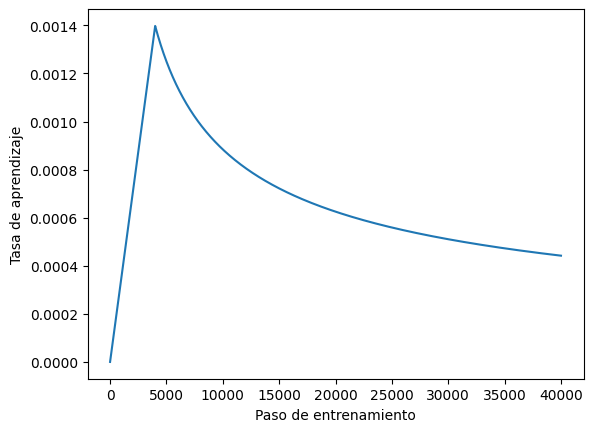

In [53]:
plt.plot(learning_rate(tf.range(40000, dtype=tf.float32)))
plt.ylabel('Tasa de aprendizaje')
plt.xlabel('Paso de entrenamiento')

### Configurar la pérdida y las métricas

Como las secuencias objetivo tienen relleno, es importante aplicar una máscara de padding al calcular la pérdida. Usa la función de pérdida de entropía cruzada (`tf.keras.losses.SparseCategoricalCrossentropy`):

In [54]:
def masked_loss(label, pred):
  mask = label != 0
  loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')
  loss = loss_object(label, pred)

  mask = tf.cast(mask, dtype=loss.dtype)
  loss *= mask

  loss = tf.reduce_sum(loss)/tf.reduce_sum(mask)
  return loss


def masked_accuracy(label, pred):
  pred = tf.argmax(pred, axis=2)
  label = tf.cast(label, pred.dtype)
  match = label == pred

  mask = label != 0

  match = match & mask

  match = tf.cast(match, dtype=tf.float32)
  mask = tf.cast(mask, dtype=tf.float32)
  return tf.reduce_sum(match)/tf.reduce_sum(mask)

### Entrenar el modelo

Con todos los componentes preparados, configura el procedimiento de entrenamiento con `model.compile` y ejecútalo con `model.fit`:

> Nota: En Colab, este entrenamiento tarda alrededor de una hora.

In [55]:
transformer.compile(
    loss=masked_loss,
    optimizer=optimizer,
    metrics=[masked_accuracy])

In [ ]:
transformer.fit(train_batches,
                epochs=20,
                validation_data=val_batches)

## Ejecutar inferencia

Ahora puedes probar el modelo realizando una traducción. En inferencia se siguen estos pasos:

* Codificar la frase de entrada con el tokenizador de portugués (`tokenizers.pt`). Esta es la entrada del codificador.
* Inicializar la entrada del decodificador con el token `[START]`.
* Calcular las máscaras de padding y las máscaras de anticipación (*look-ahead*).
* El `decoder` produce predicciones atendiendo tanto a la `encoder output` como a su propia salida parcial mediante autoatención.
* Concatenar el token predicho a la entrada del decodificador y volver a pasarlo por el decodificador.
* Con este enfoque, el decodificador predice el siguiente token a partir de los tokens que ya ha predicho.

Nota: El modelo está optimizado para un _entrenamiento eficiente_ y predice el siguiente token para cada token de la salida de forma simultánea. Durante la inferencia esto es redundante, ya que solo se usa la última predicción. La inferencia podría hacerse más eficiente si en modo inferencia (`training=False`) solo se calculara la última predicción.

Define la clase `Translator` extendiendo `tf.Module`:

In [56]:
class Translator(tf.Module):
  def __init__(self, tokenizers, transformer):
    self.tokenizers = tokenizers
    self.transformer = transformer

  def __call__(self, sentence, max_length=MAX_TOKENS):
    # La frase de entrada está en portugués; por eso se añaden los tokens `[START]` y `[END]`.
    assert isinstance(sentence, tf.Tensor)
    if len(sentence.shape) == 0:
      sentence = sentence[tf.newaxis]

    sentence = self.tokenizers.pt.tokenize(sentence).to_tensor()

    encoder_input = sentence

    # Como el idioma de salida es inglés, inicializa la salida con el
    # token inglés `[START]`.
    start_end = self.tokenizers.en.tokenize([''])[0]
    start = start_end[0][tf.newaxis]
    end = start_end[1][tf.newaxis]

    # Aquí se requiere `tf.TensorArray` (en lugar de una lista de Python) para que
    # `tf.function` pueda trazar el bucle dinámico.
    output_array = tf.TensorArray(dtype=tf.int64, size=0, dynamic_size=True)
    output_array = output_array.write(0, start)

    for i in tf.range(max_length):
      output = tf.transpose(output_array.stack())
      predictions = self.transformer([encoder_input, output], training=False)

      # Selecciona el último token de la dimensión `seq_len`.
      predictions = predictions[:, -1:, :]  # Forma `(batch_size, 1, vocab_size)`.

      predicted_id = tf.argmax(predictions, axis=-1)

      # Concatena `predicted_id` a la salida que se entrega al
      # decodificador como entrada.
      output_array = output_array.write(i+1, predicted_id[0])

      if predicted_id == end:
        break

    output = tf.transpose(output_array.stack())
    # La forma de la salida es `(1, tokens)`.
    text = tokenizers.en.detokenize(output)[0]  # Forma: `()`.

    tokens = tokenizers.en.lookup(output)[0]

    # `tf.function` impide usar los attention_weights calculados
    # en la última iteración del bucle.
    # Por eso se recalculan fuera del bucle.
    self.transformer([encoder_input, output[:,:-1]], training=False)
    attention_weights = self.transformer.decoder.last_attn_scores

    return text, tokens, attention_weights

> Nota: Esta función usa un bucle desenrollado, no un bucle dinámico. Genera hasta `MAX_TOKENS` en cada llamada. Consulta el tutorial de [NMT con atención](nmt_with_attention.ipynb) para ver un ejemplo de implementación con bucle dinámico, que puede ser mucho más eficiente.

Crea una instancia de esta clase `Translator` y pruébala varias veces:

In [ ]:
# NOTE: Aquí cargamos un modelo ya entrenado. Si has entrenado tu propio modelo,
# puedes obviar esta celda y ejecutar la siguiente para crear un traductor con tu modelo.
translator = tf.saved_model.load('translator')

In [ ]:
# NOTE: Si has entrenado tu propio modelo, ejecuta esta celda para crear un traductor con tu modelo.
# Si prefieres cargar un modelo preentrenado, obvia esta celda y ejecuta la anterior.
translator = Translator(tokenizers, transformer)

In [69]:
def print_translation(sentence, tokens, ground_truth):
  print(f'{"Entrada:":15s}: {sentence}')
  print(f'{"Predicción":15s}: {tokens.numpy().decode("utf-8")}')
  print(f'{"Valor real":15s}: {ground_truth}')

Ejemplo 1:

In [71]:
sentence = 'este é um problema que temos que resolver.'
ground_truth = 'this is a problem we have to solve .'

translated_text = translator(sentence)
print_translation(sentence, translated_text, ground_truth)

Entrada:       : este é um problema que temos que resolver.
Predicción     : this is a problem that we have to solve it .
Valor real     : this is a problem we have to solve .


Ejemplo 2:

In [73]:
sentence = 'os meus vizinhos ouviram sobre esta ideia.'
ground_truth = 'and my neighboring homes heard about this idea .'

translated_text = translator(sentence)
print_translation(sentence, translated_text, ground_truth)

Entrada:       : os meus vizinhos ouviram sobre esta ideia.
Predicción     : my neighbors had heard about this idea . this idea .
Valor real     : and my neighboring homes heard about this idea .


Ejemplo 3:

In [72]:
sentence = 'vou então muito rapidamente partilhar convosco algumas histórias de algumas coisas mágicas que aconteceram.'
ground_truth = "so i'll just share with you some stories very quickly of some magical things that have happened."

translated_text = translator(sentence)
print_translation(sentence, translated_text, ground_truth)

Entrada:       : vou então muito rapidamente partilhar convosco algumas histórias de algumas coisas mágicas que aconteceram.
Predicción     : so i ' ll play very rapidly share with you some kind of things in some pretty magical stories of things happened here .
Valor real     : so i'll just share with you some stories very quickly of some magical things that have happened.


## Crear gráficos de atención

La clase `Translator` creada en la sección anterior devuelve un diccionario de mapas de calor de atención que puedes usar para visualizar el funcionamiento interno del modelo.

Por ejemplo:

In [ ]:
sentence = 'este é o primeiro livro que eu fiz.'
ground_truth = "this is the first book i've ever done."

translated_text, translated_tokens, attention_weights = translator(
    tf.constant(sentence))
print_translation(sentence, translated_text, ground_truth)

Crea una función que grafique la atención cuando se genera un token:

In [ ]:
def plot_attention_head(in_tokens, translated_tokens, attention):
  # El modelo no generó `<START>` en la salida. Se omite.
  translated_tokens = translated_tokens[1:]

  ax = plt.gca()
  ax.matshow(attention)
  ax.set_xticks(range(len(in_tokens)))
  ax.set_yticks(range(len(translated_tokens)))

  labels = [label.decode('utf-8') for label in in_tokens.numpy()]
  ax.set_xticklabels(
      labels, rotation=90)

  labels = [label.decode('utf-8') for label in translated_tokens.numpy()]
  ax.set_yticklabels(labels)

In [ ]:
head = 0
# Forma: `(batch=1, num_heads, seq_len_q, seq_len_k)`.
attention_heads = tf.squeeze(attention_weights, 0)
attention = attention_heads[head]
attention.shape

Estos son los tokens de entrada (portugués):

In [ ]:
in_tokens = tf.convert_to_tensor([sentence])
in_tokens = tokenizers.pt.tokenize(in_tokens).to_tensor()
in_tokens = tokenizers.pt.lookup(in_tokens)[0]
in_tokens

Y estos son los tokens de salida (traducción al inglés):

In [ ]:
translated_tokens

In [ ]:
plot_attention_head(in_tokens, translated_tokens, attention)

In [ ]:
def plot_attention_weights(sentence, translated_tokens, attention_heads):
  in_tokens = tf.convert_to_tensor([sentence])
  in_tokens = tokenizers.pt.tokenize(in_tokens).to_tensor()
  in_tokens = tokenizers.pt.lookup(in_tokens)[0]

  fig = plt.figure(figsize=(16, 8))

  for h, head in enumerate(attention_heads):
    ax = fig.add_subplot(2, 4, h+1)

    plot_attention_head(in_tokens, translated_tokens, head)

    ax.set_xlabel(f'Cabeza {h+1}')

  plt.tight_layout()
  plt.show()

In [ ]:
plot_attention_weights(sentence,
                       translated_tokens,
                       attention_weights[0])

El modelo puede manejar palabras desconocidas. Ni `'triceratops'` ni `'encyclopédia'` están en el conjunto de datos de entrada, y aun así el modelo intenta transliterarlas incluso sin vocabulario compartido. Por ejemplo:

In [ ]:
sentence = 'Eu li sobre triceratops na enciclopédia.'
ground_truth = 'I read about triceratops in the encyclopedia.'

translated_text, translated_tokens, attention_weights = translator(
    tf.constant(sentence))
print_translation(sentence, translated_text, ground_truth)

plot_attention_weights(sentence, translated_tokens, attention_weights[0])

## Exportar el modelo

Ya has probado el modelo y la inferencia funciona. A continuación puedes exportarlo como `tf.saved_model`. Para aprender sobre guardado y carga de modelos en formato SavedModel, usa [esta guía](https://www.tensorflow.org/guide/saved_model).

Crea una clase llamada `ExportTranslator` extendiendo la subclase `tf.Module` con una `tf.function` en el método `__call__`:

In [ ]:
class ExportTranslator(tf.Module):
  def __init__(self, translator):
    self.translator = translator

  @tf.function(input_signature=[tf.TensorSpec(shape=[], dtype=tf.string)])
  def __call__(self, sentence):
    (result,
     tokens,
     attention_weights) = self.translator(sentence, max_length=MAX_TOKENS)

    return result

En la `tf.function` anterior solo se devuelve la frase de salida. Gracias a la [ejecución no estricta](https://tensorflow.org/guide/intro_to_graphs) de `tf.function`, los valores innecesarios no llegan a calcularse.

Envuelve `translator` con la clase `ExportTranslator` recién creada:

In [ ]:
translator = ExportTranslator(translator)

Como el modelo decodifica las predicciones usando `tf.argmax`, las predicciones son deterministas. El modelo original y otro recargado desde su `SavedModel` deberían producir predicciones idénticas:

In [ ]:
translator('este é o primeiro livro que eu fiz.').numpy()

In [ ]:
tf.saved_model.save(translator, export_dir='translator')

In [ ]:
reloaded = tf.saved_model.load('translator')

In [ ]:
reloaded('este é o primeiro livro que eu fiz.').numpy()

In [ ]:
reloaded_2 = tf.saved_model.load('translator')
reloaded_2('este é o primeiro livro que eu fiz.').numpy()

## Conclusión

En este tutorial has aprendido sobre:

* Los Transformers y su importancia en aprendizaje automático.
* Atención, autoatención y atención multicabeza.
* Codificación posicional con embeddings.
* La arquitectura codificador-decodificador del Transformer original.
* Enmascaramiento en autoatención.
* Cómo unir todas las piezas para traducir texto.

Las desventajas de esta arquitectura son:

- En una serie temporal, la salida de un paso temporal se calcula a partir de *toda la historia* en lugar de usar solo las entradas y el estado oculto actual. Esto _puede_ ser menos eficiente.
- Si la entrada tiene una relación temporal o espacial, como texto o imágenes, hay que añadir algún tipo de codificación posicional; de lo contrario, el modelo verá efectivamente una bolsa de palabras.

Si quieres practicar, hay muchas cosas que puedes probar. Por ejemplo:

* Usar un conjunto de datos distinto para entrenar el Transformer.
* Crear las configuraciones "Base Transformer" o "Transformer XL" del artículo original modificando los hiperparámetros.
* Usar las capas definidas aquí para crear una implementación de [BERT](https://arxiv.org/abs/1810.04805).
* Usar búsqueda por haces (*beam search*) para obtener mejores predicciones.

Existe una amplia variedad de modelos basados en Transformers, muchos de los cuales mejoran la versión original de 2017 con arquitecturas codificador-decodificador, solo codificador y solo decodificador.

Algunos de estos modelos se tratan en las siguientes publicaciones de investigación:

* ["Efficient Transformers: a survey"](https://arxiv.org/abs/2009.06732) (Tay et al., 2022)
* ["Formal algorithms for Transformers"](https://arxiv.org/abs/2207.09238) (Phuong and Hutter, 2022).
* [T5 ("Exploring the limits of transfer learning with a unified text-to-text Transformer")](https://arxiv.org/abs/1910.10683) (Raffel et al., 2019)

Puedes aprender más sobre otros modelos en las siguientes entradas del blog de Google:

* [PaLM](https://ai.googleblog.com/2022/04/pathways-language-model-palm-scaling-to.html).
* [LaMDA](https://ai.googleblog.com/2022/01/lamda-towards-safe-grounded-and-high.html)
* [MUM](https://blog.google/products/search/introducing-mum/)
* [Reformer](https://ai.googleblog.com/2020/01/reformer-efficient-transformer.html)
* [BERT](https://ai.googleblog.com/2018/11/open-sourcing-bert-state-of-art-pre.html)

Si te interesa estudiar cómo se han aplicado modelos basados en atención a tareas fuera del procesamiento del lenguaje natural, revisa estos recursos:

- Vision Transformer (ViT): [Transformers for image recognition at scale](https://ai.googleblog.com/2020/12/transformers-for-image-recognition-at.html)
- [Transcripción musical multipista multitarea (MT3)](https://magenta.tensorflow.org/transcription-with-transformers) con un Transformer
- [Generación de código con AlphaCode](https://www.deepmind.com/blog/competitive-programming-with-alphacode)
- [Aprendizaje por refuerzo con decision Transformers multijuego](https://ai.googleblog.com/2022/07/training-generalist-agents-with-multi.html)
- [Predicción de estructura de proteínas con AlphaFold](https://www.nature.com/articles/s41586-021-03819-2)
- [OptFormer: hacia la optimización universal de hiperparámetros con Transformers](http://ai.googleblog.com/2022/08/optformer-towards-universal.html)